<a href="https://colab.research.google.com/github/rafli-akbar-eka-saputra/PROJECT-COMPUTER-VISION/blob/main/Dataset_Banana_Diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="8FQy9APR0gDQFffC5moS")
project = rf.workspace("uhuru069").project("banana-disease-tbmmy")
version = project.version(2)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...


In [20]:
import os
import pandas as pd

data = []
for split in ["train", "valid", "test"]:
    split_path = os.path.join(dataset.location, split)
    if not os.path.exists(split_path):
        continue
    for kelas in os.listdir(split_path):
        kelas_path = os.path.join(split_path, kelas)
        if os.path.isdir(kelas_path):
            for file in os.listdir(kelas_path):
                data.append({"path": os.path.join(kelas_path, file), "label": kelas, "split": split})

df = pd.DataFrame(data)
df.head()

,path,label,split
0,/content/Banana-Disease-2/train/Panama Disease...,Panama Disease,train
1,/content/Banana-Disease-2/train/Panama Disease...,Panama Disease,train
2,/content/Banana-Disease-2/train/Panama Disease...,Panama Disease,train
3,/content/Banana-Disease-2/train/Panama Disease...,Panama Disease,train
4,/content/Banana-Disease-2/train/Panama Disease...,Panama Disease,train


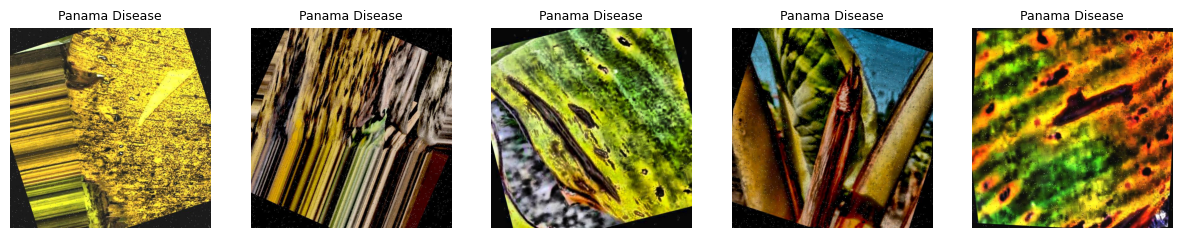

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

def show_head(df, n=5):
    plt.figure(figsize=(3 * n, 3))
    for i, row in enumerate(df.head(n).itertuples()):
        plt.subplot(1, n, i + 1)
        plt.imshow(Image.open(row.path))
        plt.title(row.label, fontsize=9)
        plt.axis("off")
    plt.show()

show_head(df)